<a href="https://colab.research.google.com/github/NeevSabhani/Data-Science/blob/main/Unit6%20-%20Generalized%20Linear%20Models/%20Copy_of_MultLinExercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 11.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
from google.colab.output import eval_js
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import graphviz as gv
import arviz as az
import pymc as pm
import bambi as bmb

## EBLercises

You may use whatever resources you want to complete these eBLercises, so long as you cite your sources and the use of AI.

I recommend copying and pasting from the eBLamples I did [here](https://github.com/thedarredondo/data-science-fundamentals/BLob/main/FastTrack/IntroMultLinSF.ipynb); giving you something to copy and paste from was half my intent in writing that lesson.

**Task1**

Get the [penguins data from my github page](https://github.com/thedarredondo/data-science-fundamentals/BLob/main/Data/penguins.csv) into this colab document.

I suggest downloading the csv, and then using the code from [notes document](https://github.com/thedarredondo/data-science-fundamentals/BLob/main/FastTrack/IntroMultLinSF.ipynb) to upload it into this jupyter notebook.

In [ ]:
file_path = '/content/penguins.csv'
penguins = pd.read_csv(file_path)
penguins = penguins.dropna()

penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


**Task2**

Make a pair plot with the penguins data and describe the scatter plots. Make sure to describe any patterns.

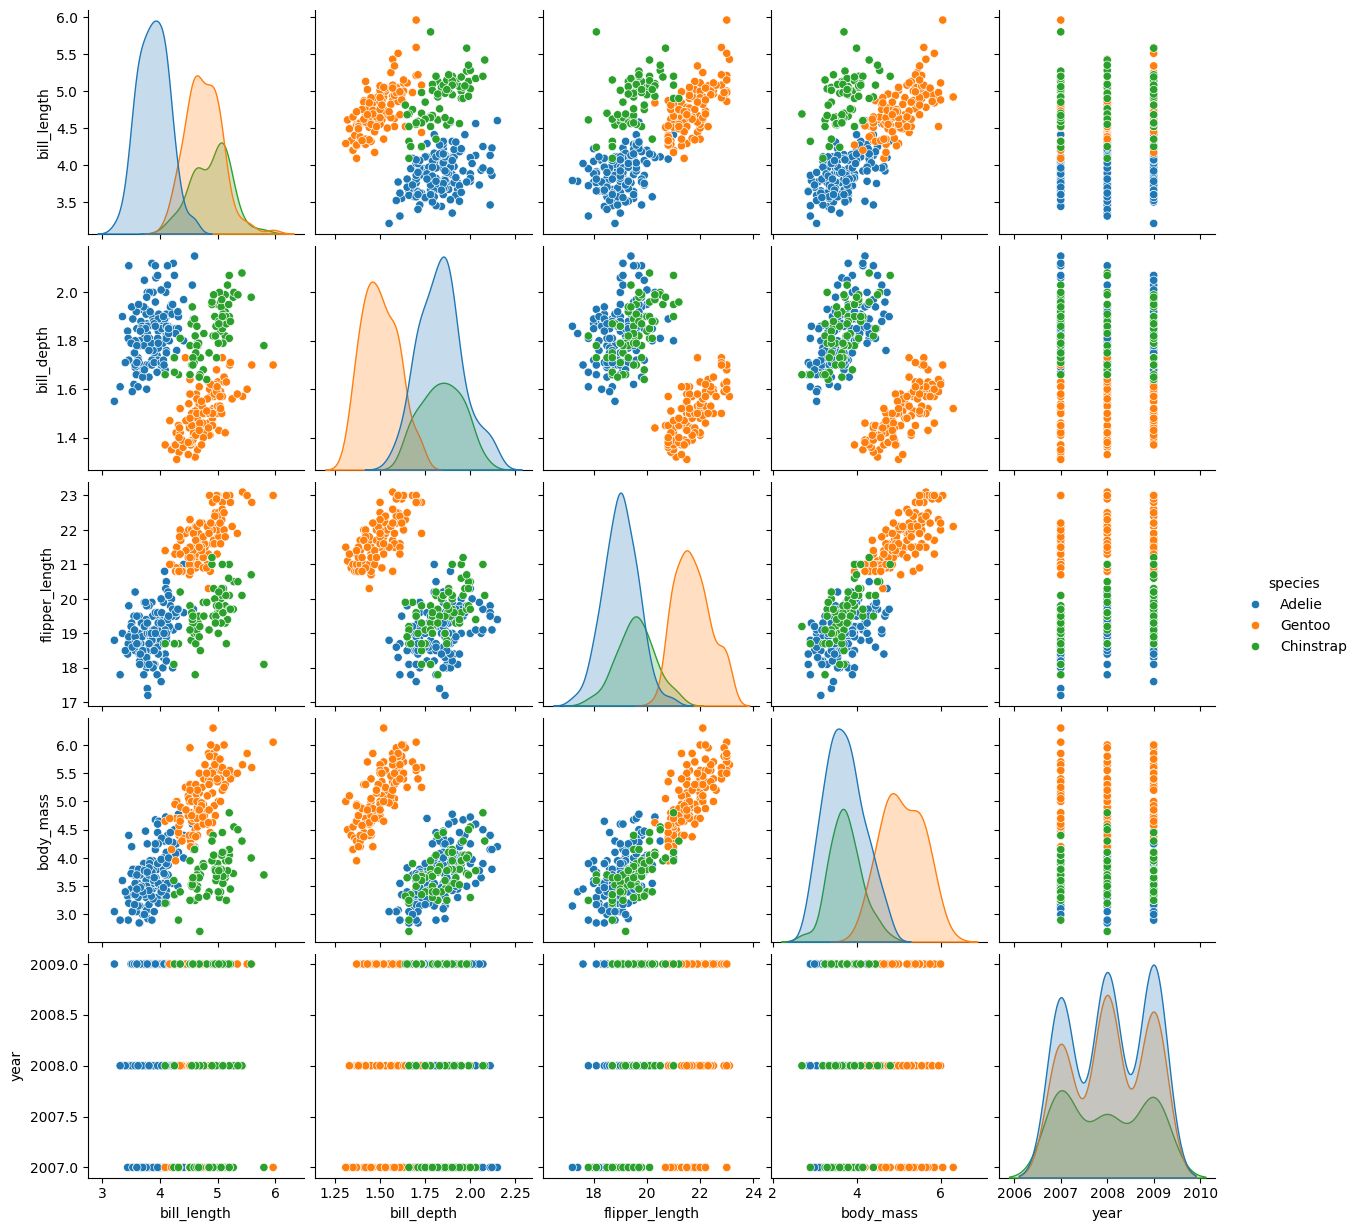

In [ ]:
sns.pairplot(penguins, hue = "species")

I can see positive correlations in plots like bill depth vs body mass and so on. This is what I will look at when I make my casual diagram because that shows there is correlation -> Interaction in my model. Island and Species dont show up (I think because they are categorical)  but I'll add to my casual diagram using my knowledge.

**Task3**

Make a causal diagram corresponding to the penguins data. Remember to include the species variable, even though it likely didn't show up in your pair plot.

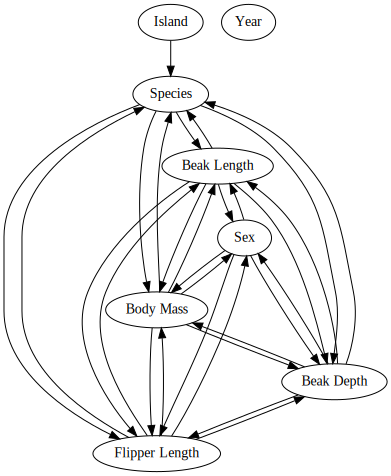

In [ ]:
s_dag = gv.Digraph(name="Penguin DAG")

s_dag.node('S','Species')
s_dag.node('I','Island')
s_dag.node('X','Beak Length')
s_dag.node('F','Flipper Length')
s_dag.node('D','Beak Depth')
s_dag.node('M','Body Mass')
s_dag.node('G','Sex')
s_dag.node('Y','Year')

s_dag.edges(['IS', 'SX', 'SF', 'SD', 'SM', 'XS'])
s_dag.edges(['XD', 'DX', 'XF', 'FX', 'XM', 'MX', 'FD', 'DF', 'FM', 'MF', 'DM', 'MD'])
s_dag.edges(['GD', 'GM', 'XG', 'FG', 'DG', 'MG'])
s_dag.edges(['FS', 'DS', 'MS', 'GX', 'GF'])

s_dag

**Task4**

Create a Bayesian generalized linear model (GLM) to represent and test your causal diagram.

Then, conduct both types of posterior predictve check, and use them to comment on the model's fit. Note that you may want to make several plots here.

You may use another model type if want--[such as BART](https://github.com/thedarredondo/data-science-fundamentals/BLob/main/Unit8/Unit8NotesSF.ipynb)--so long as it is Bayesian, and it represents your causal diagram.

Output()

<Axes: xlabel='flipper_length'>

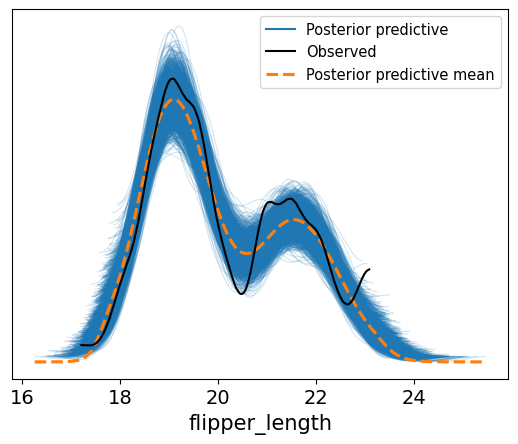

In [ ]:
model_penguin = bmb.Model(
    "flipper_length ~ species + island + sex + bill_length + bill_depth + body_mass + bill_length:bill_depth + bill_length:body_mass + bill_depth:body_mass + sex:bill_length + sex:bill_depth + sex:body_mass",
    data=penguins
)
model_penguin
idata_penguin = model_penguin.fit(idata_kwargs={"log_likelihood":True})
model_penguin.predict(idata_penguin, kind="response")
az.plot_ppc(idata_penguin)

**Task5**

Create as many other models as you need to test your causal hypotheses.

Then, "test" those causal hypotheses using the az.compare and az.plot_compare() functions.

Output()

<Axes: xlabel='flipper_length'>

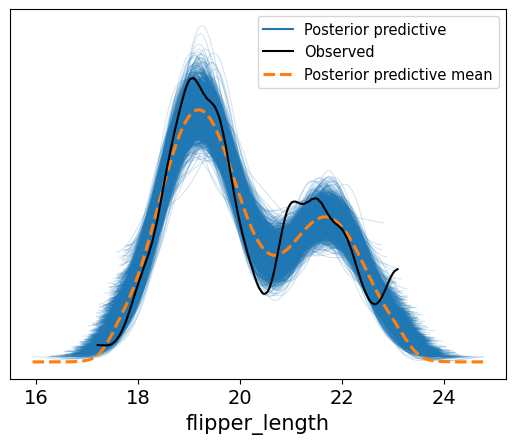

In [ ]:
# Model 1 - No interactions
model_penguin_1 = bmb.Model(
    "flipper_length ~ species + island + sex + bill_length + bill_depth + body_mass",
    data=penguins
)
idata_penguin_1 = model_penguin_1.fit(idata_kwargs={"log_likelihood":True})
model_penguin_1.predict(idata_penguin_1, kind="response")
az.plot_ppc(idata_penguin_1)

Output()

<Axes: xlabel='flipper_length'>

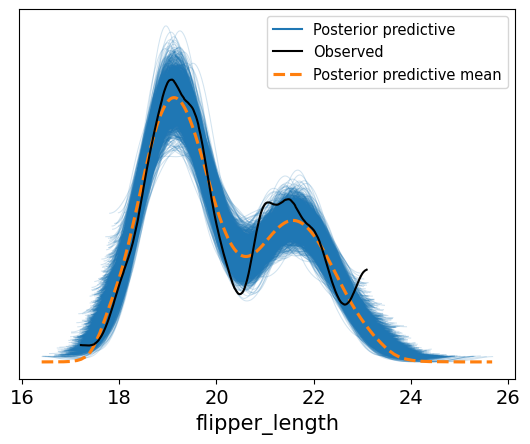

In [ ]:
# Model 2 - Drop sex and its interactions
model_penguin_2 = bmb.Model(
    "flipper_length ~ species + island + bill_length + bill_depth + body_mass + bill_length:bill_depth + bill_length:body_mass + bill_depth:body_mass",
    data=penguins
)
idata_penguin_2 = model_penguin_2.fit(idata_kwargs={"log_likelihood":True})
model_penguin_2.predict(idata_penguin_2, kind="response")
az.plot_ppc(idata_penguin_2)

Output()

<Axes: xlabel='flipper_length'>

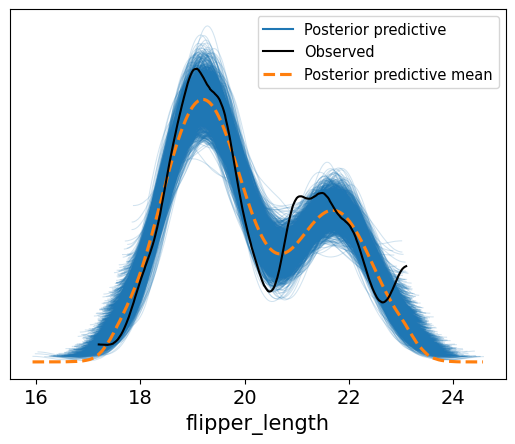

In [ ]:
# Model 3 - Minimal
model_penguin_3 = bmb.Model(
    "flipper_length ~ species + island + body_mass",
    data=penguins
)
idata_penguin_3 = model_penguin_3.fit(idata_kwargs={"log_likelihood":True})
model_penguin_3.predict(idata_penguin_3, kind="response")
az.plot_ppc(idata_penguin_3)

Output()

<Axes: xlabel='flipper_length'>

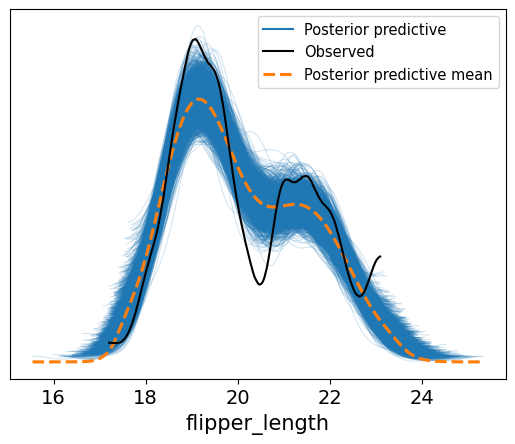

In [ ]:
# Model 4 - Beak measurements + sex interactions only
model_penguin_4 = bmb.Model(
    "flipper_length ~ sex + bill_length + bill_depth + body_mass + sex:bill_length + sex:bill_depth + sex:body_mass",
    data=penguins
)
idata_penguin_4 = model_penguin_4.fit(idata_kwargs={"log_likelihood":True})
model_penguin_4.predict(idata_penguin_4, kind="response")
az.plot_ppc(idata_penguin_4)

In [ ]:

df_compare = az.compare({
    "full_dag":       idata_penguin,
    "no_interact":    idata_penguin_1,
    "no_sex":         idata_penguin_2,
    "minimal":        idata_penguin_3,
    "no_species":     idata_penguin_4,
})
df_compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
full_dag,0,-253.260861,15.514816,0.000000,0.451955,14.052511,0.000000,False,log
no_sex,1,-254.178753,11.985541,0.917892,0.462823,14.824547,3.336976,False,log
no_interact,2,-261.068227,10.828844,7.807366,0.000000,14.826479,5.409992,False,log
minimal,3,-269.906684,7.280222,16.645823,0.000000,13.534545,6.086792,False,log
no_species,4,-284.627297,8.769927,31.366436,0.085222,12.840503,8.441471,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

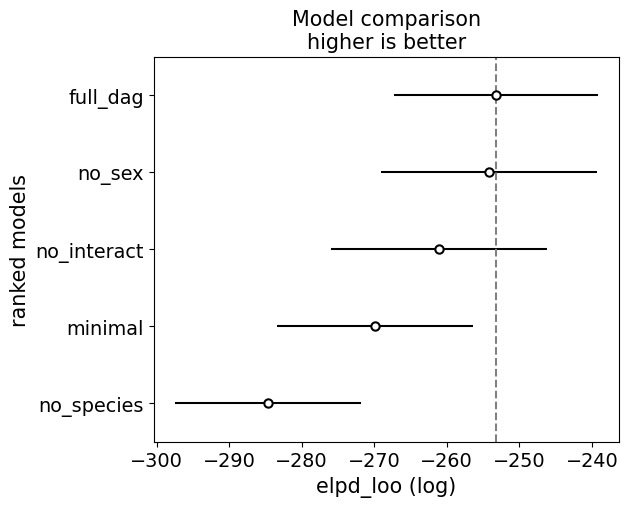

In [ ]:
az.plot_compare(df_compare)

**My Original Model was the best**

**Task6**

Answer the following:

- Which variables were most important?

- Was that surprising? Why?

- Did the model representing your causal diagram perform worse or better than other models?

- What did you learn about the data--and about penguins--from your models?

Which variables were most important?
Species came out as the most important variable. Removing species tanked the model really badly. Having no interactions and having a minimal model tanked, but not as much as removing species all together. Sex barelly mattered for me.

Was that surprising? Why?
Species dominating wasn't surprising since different penguin species are just physically different animals. The sex being essentially useless was super surprising to me though. Most, including me, would assume that sex would play a heavy role into the flipper length because of genetical differences and stuff but that was not the case according to my model.


Did the full DAG model perform better or worse?
It performed the best, sitting furthest right on the plot. This is a good sign because it means making the causal diagram  helped rather than just adding noise to the model. However, no sex was a fraction of an inch behind so...


What did you learn about the data and penguins?
I learned that apparently, sex does not matter that much for flipper length for a penguin. For the data, I learned that Island pulled some weight in the model, but the best assumption is that it is just catching the species differences since each island essentially has its own species.